In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Part 1 — Load the data

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/behnamgavili/Introduction-to-AI/main/titanic.csv"

try:
    df = pd.read_csv("titanic.csv")
except FileNotFoundError:
    df = pd.read_csv(url)

print("Our table has", df.shape[0], "rows and", df.shape[1], "columns")

Our table has 891 rows and 12 columns


In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


Part 2 -- Look at the data

In [5]:
df.info() #column types and missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


The average of Survived is about 0.38 — only 38% survived. The average age is about 30, and ticket prices run from 0 to a spectacular 512 pounds.

In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


count categories

In [7]:

print("Survived?")
print(df["Survived"].value_counts())

print("\nSex:")
print(df["Sex"].value_counts())

print("\nTicket class:")
print(df["Pclass"].value_counts())

print("\nEmbarked:")
print(df["Embarked"].value_counts())

Survived?
Survived
0    549
1    342
Name: count, dtype: int64

Sex:
Sex
male      577
female    314
Name: count, dtype: int64

Ticket class:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Embarked:
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64



Part 4 — Insight: see the answer before modeling

This is the most important part of the notebook. Before any model, we ask the data: who survived? Every pattern we spot here is something a good model should also find — so when we build models later, we can check whether they "understood" the data.

Survival by sex

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


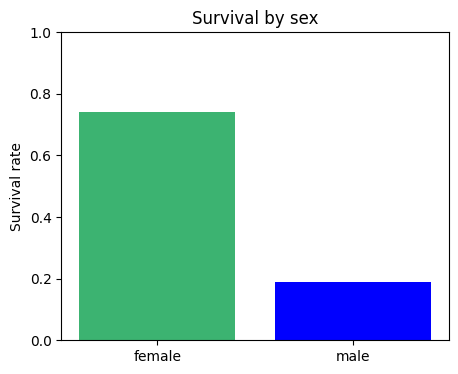

In [8]:
rate_by_sex = df.groupby("Sex")["Survived"].mean()
print(rate_by_sex)

plt.figure(figsize=(5, 4))
plt.bar(["female", "male"], rate_by_sex[["female", "male"]], color=["mediumseagreen", "blue"])
plt.ylabel("Survival rate")
plt.title("Survival by sex")
plt.ylim(0, 1)
plt.show()

A huge gap: 74% of women survived, versus 19% of men. "Women and children first" was not just a saying — it is right here in the data, a century later. This single fact is the strongest signal in the whole dataset.

Sex
female    314
male      577
Name: Survived, dtype: int64


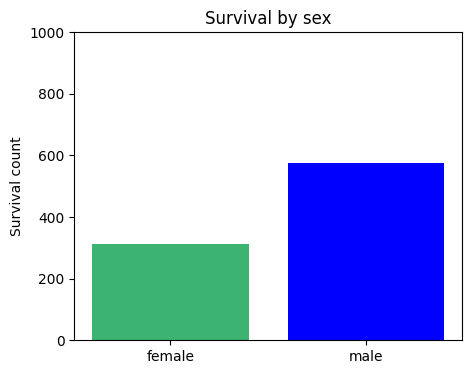

In [9]:
rate_by_sex = df.groupby("Sex")["Survived"].count()
print(rate_by_sex)

plt.figure(figsize=(5, 4))
plt.bar(["female", "male"], rate_by_sex[["female", "male"]], color=["mediumseagreen", "blue"])
plt.ylabel("Survival count")
plt.title("Survival by sex")
plt.ylim(0, 1000)
plt.show()

Survival by ticket class

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


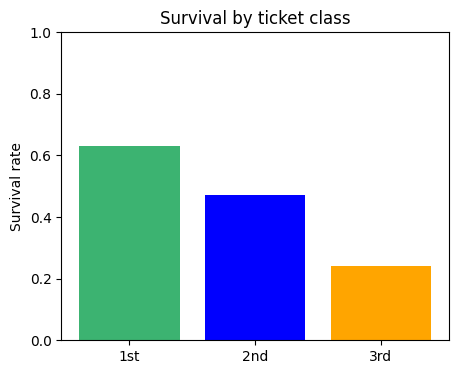

In [10]:
rate_by_class = df.groupby("Pclass")["Survived"].mean()
print(rate_by_class)

plt.figure(figsize=(5, 4))
plt.bar(["1st", "2nd", "3rd"], rate_by_class[[1, 2, 3]], color=["mediumseagreen", "blue", "orange"])
plt.ylabel("Survival rate")
plt.title("Survival by ticket class")
plt.ylim(0, 1)
plt.show()

 And the children?

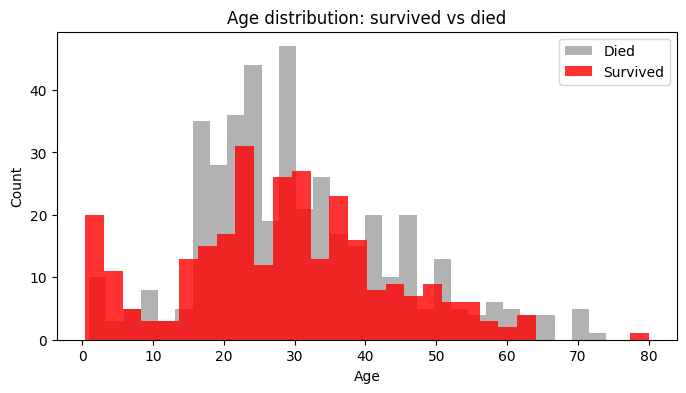

Survival rate of children under 10: 0.61
Survival rate of everyone:          0.38


In [11]:
plt.figure(figsize=(8, 4))
plt.hist(df[df["Survived"] == 0]["Age"].dropna(), bins=30, alpha=0.6, color="gray",           label="Died")
plt.hist(df[df["Survived"] == 1]["Age"].dropna(), bins=30, alpha=0.8, color="red", label="Survived")
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age distribution: survived vs died")
plt.legend()
plt.show()

print("Survival rate of children under 10:", round(df[df["Age"] < 10]["Survived"].mean(), 2))
print("Survival rate of everyone:         ", round(df["Survived"].mean(), 2))

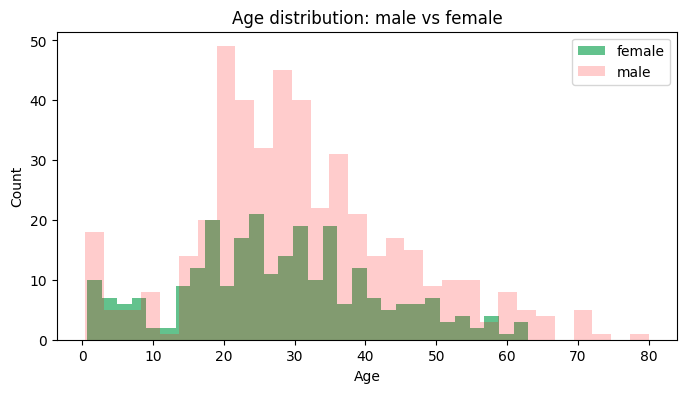

Survival rate of male: 0.19
Survival rate of male: 0.74
Survival rate of everyone:          0.38


In [12]:
plt.figure(figsize=(8, 4))
plt.hist(df[df["Sex"] == "female"]["Age"].dropna(), bins=30, alpha=0.8, color="mediumseagreen", label="female")
plt.hist(df[df["Sex"] == "male"]["Age"].dropna(), bins=30, alpha=0.2, color="red", label="male")
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age distribution: male vs female")
plt.legend()
plt.show()

print("Survival rate of male:", round(df[df["Sex"] == "male"]["Survived"].mean(), 2))
print("Survival rate of male:", round(df[df["Sex"] == "female"]["Survived"].mean(), 2))
print("Survival rate of everyone:         ", round(df["Survived"].mean(), 2))

Sex and class together

Sex     female  male
Pclass              
1         0.97  0.37
2         0.92  0.16
3         0.50  0.14


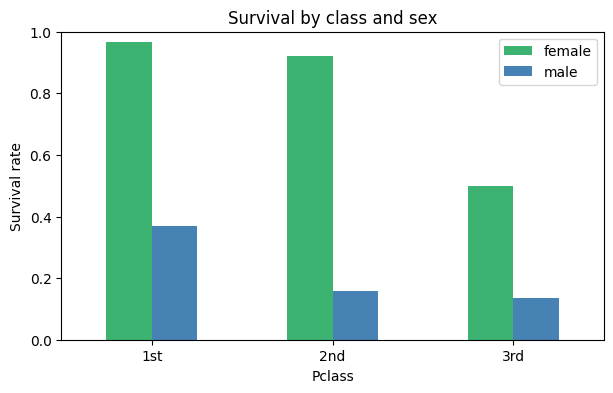

In [13]:

table = df.groupby(["Pclass", "Sex"])["Survived"].mean().unstack()
print(table.round(2))

table.plot(kind="bar", figsize=(7, 4), color=["mediumseagreen", "steelblue"])
plt.ylabel("Survival rate")
plt.title("Survival by class and sex")
plt.xticks([0, 1, 2], ["1st", "2nd", "3rd"], rotation=0)
plt.ylim(0, 1)
plt.legend(["female", "male"])
plt.show()

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


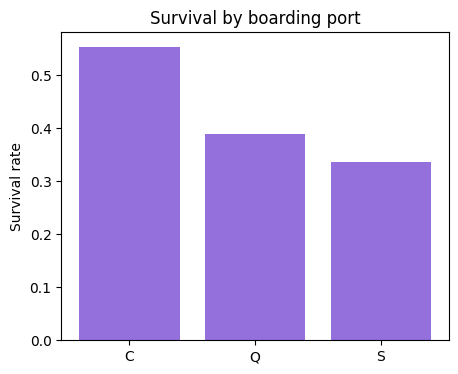

In [14]:
rate_by_port = df.groupby("Embarked")["Survived"].mean()
print(rate_by_port)

plt.figure(figsize=(5, 4))
plt.bar(["C", "Q", "S"], rate_by_port[["C", "Q", "S"]], color="mediumpurple")
plt.ylabel("Survival rate")
plt.title("Survival by boarding port")
plt.show()


Part 5 — Clean and prepare

Models need a table of numbers with no holes. We have holes (missing ages) and text (Sex, Embarked). Three fixes, same tools as last session.

5.1 Fill the holes
Missing Age → fill with the median age (28).
2 missing Embarked → fill with the most common port (S).
Cabin is missing for 687 of 891 passengers — too many holes to fill honestly, so we simply won't use it (for now… it returns in Part 9!).
One honest footnote: we compute that median from all 891 rows before splitting; strictly it should come from the training rows only, so nothing leaks from the test set. (Here both give the same 28 — real pipelines fit the imputer on the training data alone.)

In [15]:
data = df.copy()          # work on a copy, keep the original safe

data["Age"] = data["Age"].fillna(data["Age"].median())
data["Embarked"] = data["Embarked"].fillna("S")

print("Missing values now:")
print(data[["Age", "Embarked"]].isna().sum())


Missing values now:
Age         0
Embarked    0
dtype: int64


In [16]:
data[["Name", "Sex", "Sex"]].head()

,Name,Sex,Sex
0,"Braund, Mr. Owen Harris",male,male
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,female
2,"Heikkinen, Miss. Laina",female,female
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,female
4,"Allen, Mr. William Henry",male,male


In [17]:
data["Female"] = (data["Sex"] == "female").astype(int)
data = pd.get_dummies(data, columns=["Embarked"], prefix="Port")

data[["Name", "Sex", "Female", "Port_C", "Port_Q", "Port_S"]].head()

,Name,Sex,Female,Port_C,Port_Q,Port_S
0,"Braund, Mr. Owen Harris",male,0,False,False,True
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,1,True,False,False
2,"Heikkinen, Miss. Laina",female,1,False,False,True
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,1,False,False,True
4,"Allen, Mr. William Henry",male,0,False,False,True


In [18]:

FEATURES = ["Pclass", "Female", "Age", "SibSp", "Parch", "Fare",
            "Port_C", "Port_Q", "Port_S"]

X = data[FEATURES]        # features (inputs)
y = data["Survived"]      # label (what we predict)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42   # 20% for testing
)

print("Train:", len(X_train), " Test:", len(X_test))

Train: 712  Test: 179


Part 6 — First models: from a blind guess to a decision tree

In [19]:
from sklearn.metrics import accuracy_score

pred_lazy = np.zeros(len(y_test))          # 0 = "died", for everyone
acc = accuracy_score(y_test, pred_lazy)

results = {}                               # scoreboard for the whole session
results["Always 'died'"] = acc
print("Accuracy:", round(acc, 3))

Accuracy: 0.587


In [20]:
pred_one_rule = X_test["Female"]           # 1 for women, 0 for men — exactly our prediction
acc = accuracy_score(y_test, pred_one_rule)

results["One rule: sex"] = acc
print("Accuracy:", round(acc, 3))

Accuracy: 0.782


In [21]:

from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=6, random_state=42)
tree.fit(X_train, y_train)                 # learning happens here

acc = tree.score(X_test, y_test)           # .score = predict + accuracy in one step
results["Decision tree"] = acc
print("Accuracy:", round(acc, 3))

Accuracy: 0.804


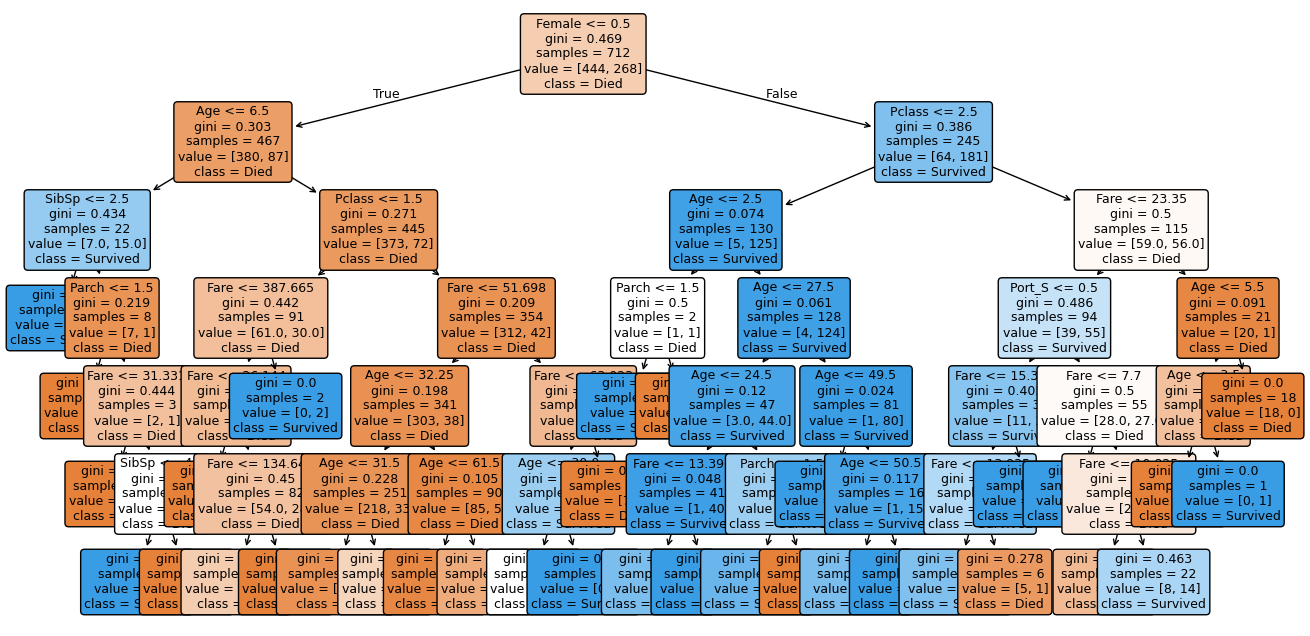

In [22]:

from sklearn.tree import plot_tree

plt.figure(figsize=(16, 8))
plot_tree(tree, feature_names=FEATURES, class_names=["Died", "Survived"],
          filled=True, rounded=True, fontsize=9)
plt.show()

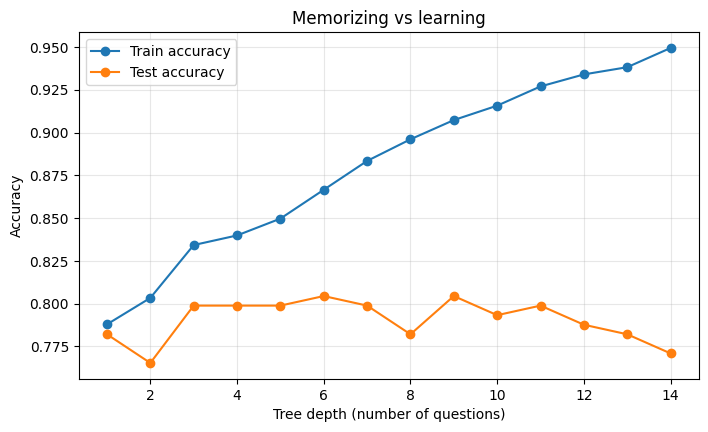

In [23]:
depths = range(1, 15)
train_acc, test_acc = [], []

for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    train_acc.append(t.score(X_train, y_train))
    test_acc.append(t.score(X_test, y_test))

plt.figure(figsize=(8, 4.5))
plt.plot(depths, train_acc, marker="o", label="Train accuracy")
plt.plot(depths, test_acc, marker="o", label="Test accuracy")
plt.xlabel("Tree depth (number of questions)")
plt.ylabel("Accuracy")
plt.title("Memorizing vs learning")
plt.legend()
plt.grid(alpha=0.3)
plt.show()